<a href="https://colab.research.google.com/github/TaruniRavipudi/RavipudiTaruni_Projects_and_Labs/blob/main/Taruni_Module2_Lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import requests
url = "https://raw.githubusercontent.com/SP9144/FMML_Data/main/Automobile_data.csv"
response = requests.get(url)

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
from io import StringIO
import matplotlib.pyplot as plt

In [3]:
# Loading the dataset
data = StringIO(response.text)
data = pd.read_csv(data)
print("Number of data points =", len(data))
data.head()

Number of data points = 205


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450


In [4]:
# Removing rows which have missing values

data.replace("?", np.nan, inplace = True)
data = data.dropna()
print(len(data))

159


In [5]:
# Dividing the dataset into features (X) and the target variable (y)

X = data.drop("price", axis = 1)
y = pd.to_numeric(data["price"])

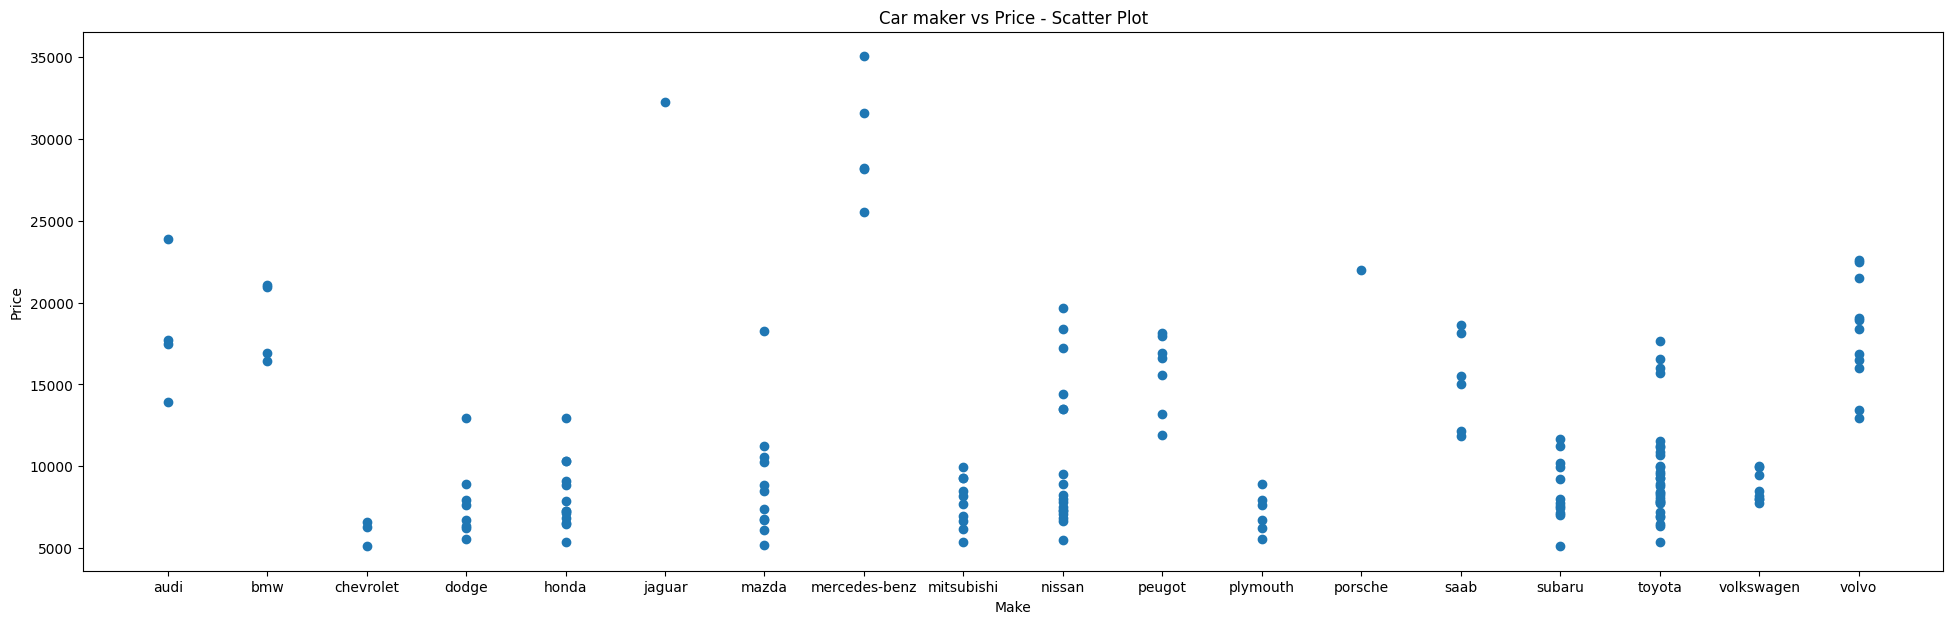

In [6]:
plt.figure(figsize = (24, 7))
plt.scatter(X["make"], y)
plt.xlabel('Make')
plt.ylabel('Price')
plt.title('Car maker vs Price - Scatter Plot')
plt.show()

/tmp/ipykernel_2308/892029043.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=X["make"],y=y, palette="Set3").set_title('Car Manufacturer vs Price - Box Plot')


Text(0.5, 1.0, 'Car Manufacturer vs Price - Box Plot')

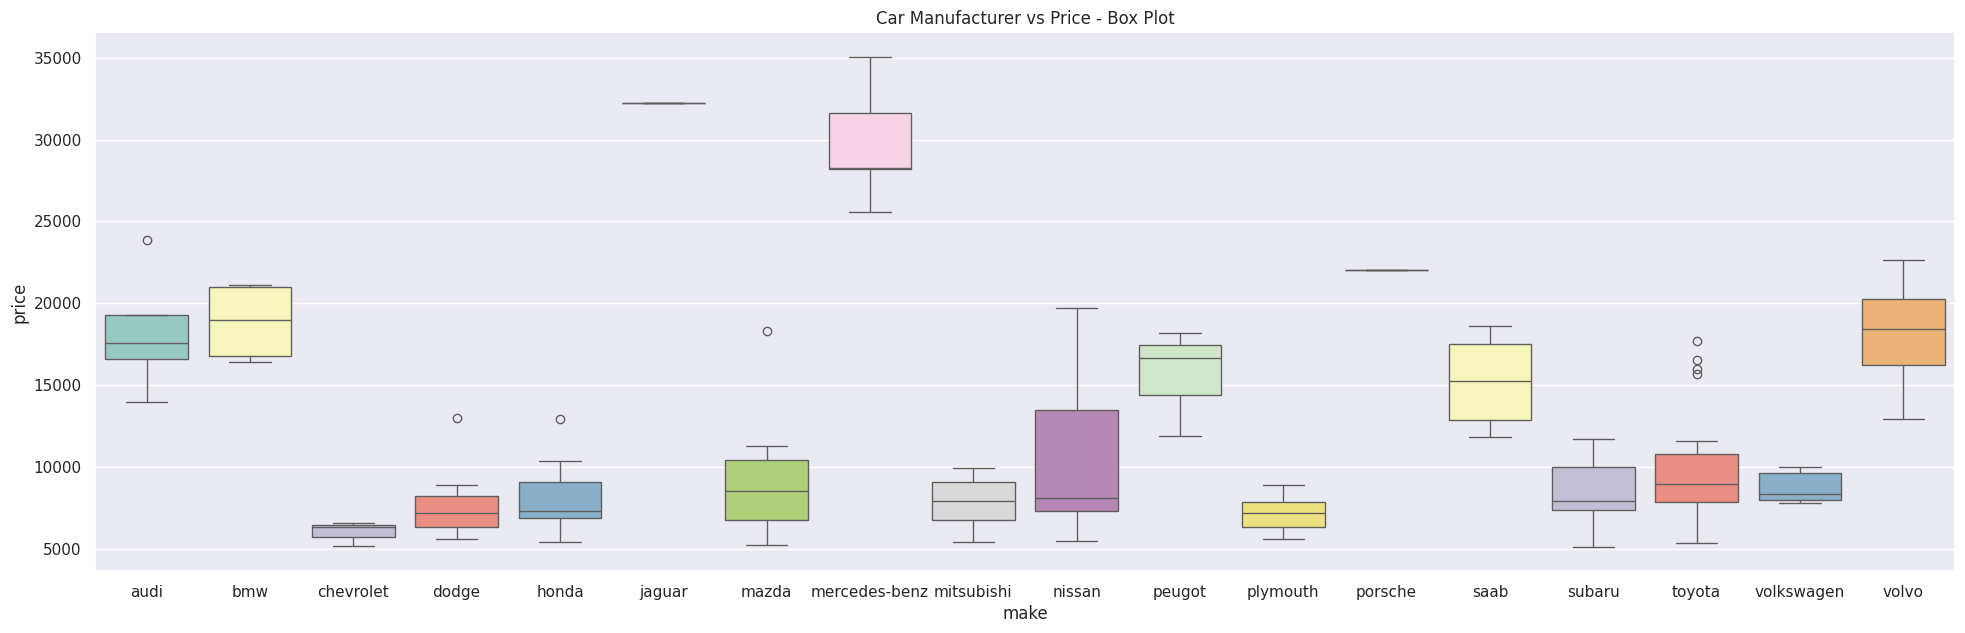

In [7]:
sns.set(rc={'figure.figsize':(24,7)})
sns.boxplot(x=X["make"],y=y, palette="Set3").set_title('Car Manufacturer vs Price - Box Plot')

/tmp/ipykernel_2308/426109079.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=X["make"],y=y, palette="Set3").set_title('Car maker vs Price - Violin Plot')


Text(0.5, 1.0, 'Car maker vs Price - Violin Plot')

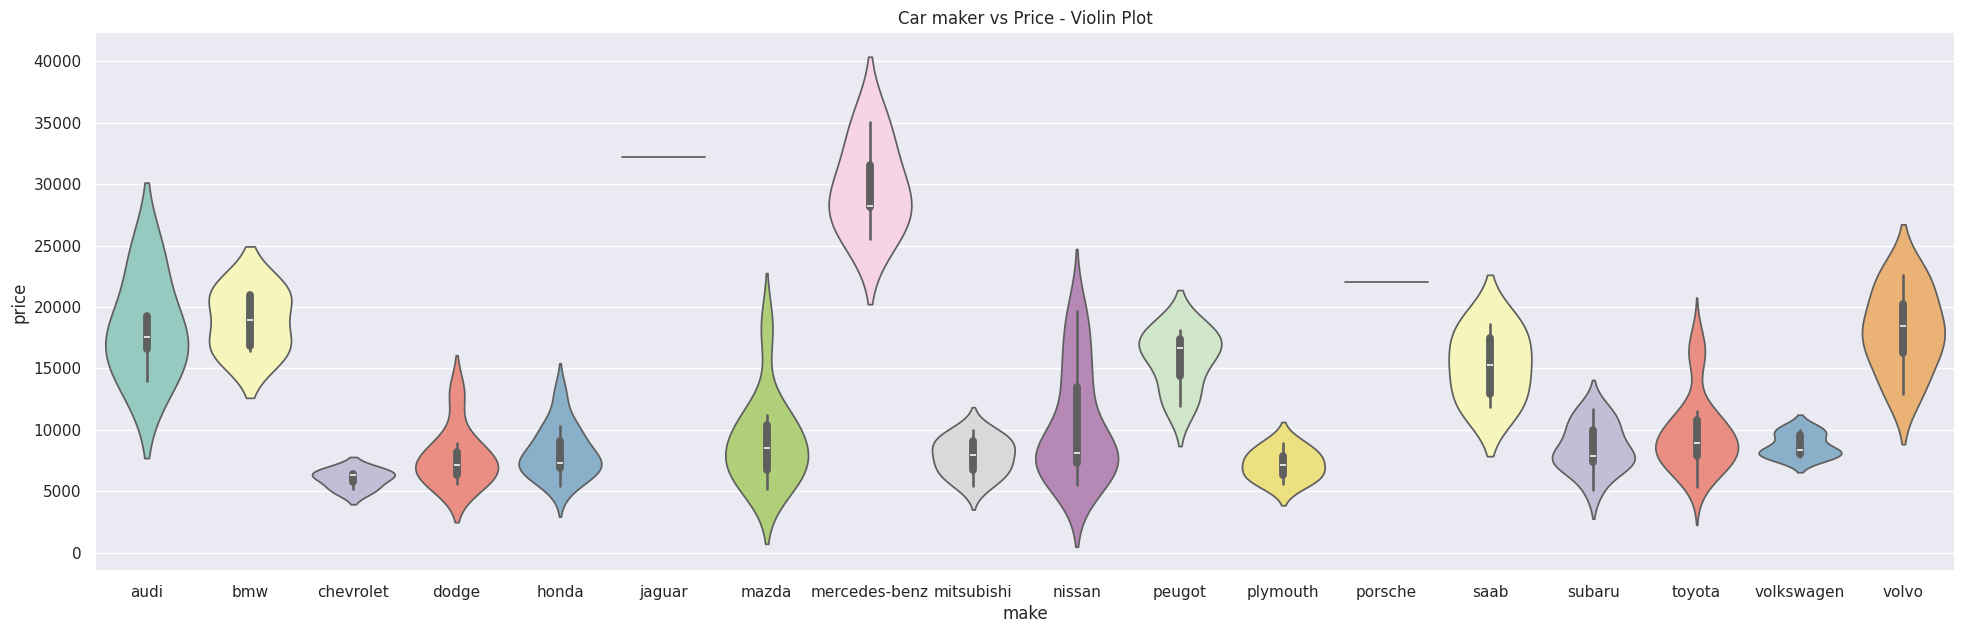

In [8]:
sns.violinplot(x=X["make"],y=y, palette="Set3").set_title('Car maker vs Price - Violin Plot')

Text(0.5, 1.0, 'Car maker vs Price Swarm Plot')

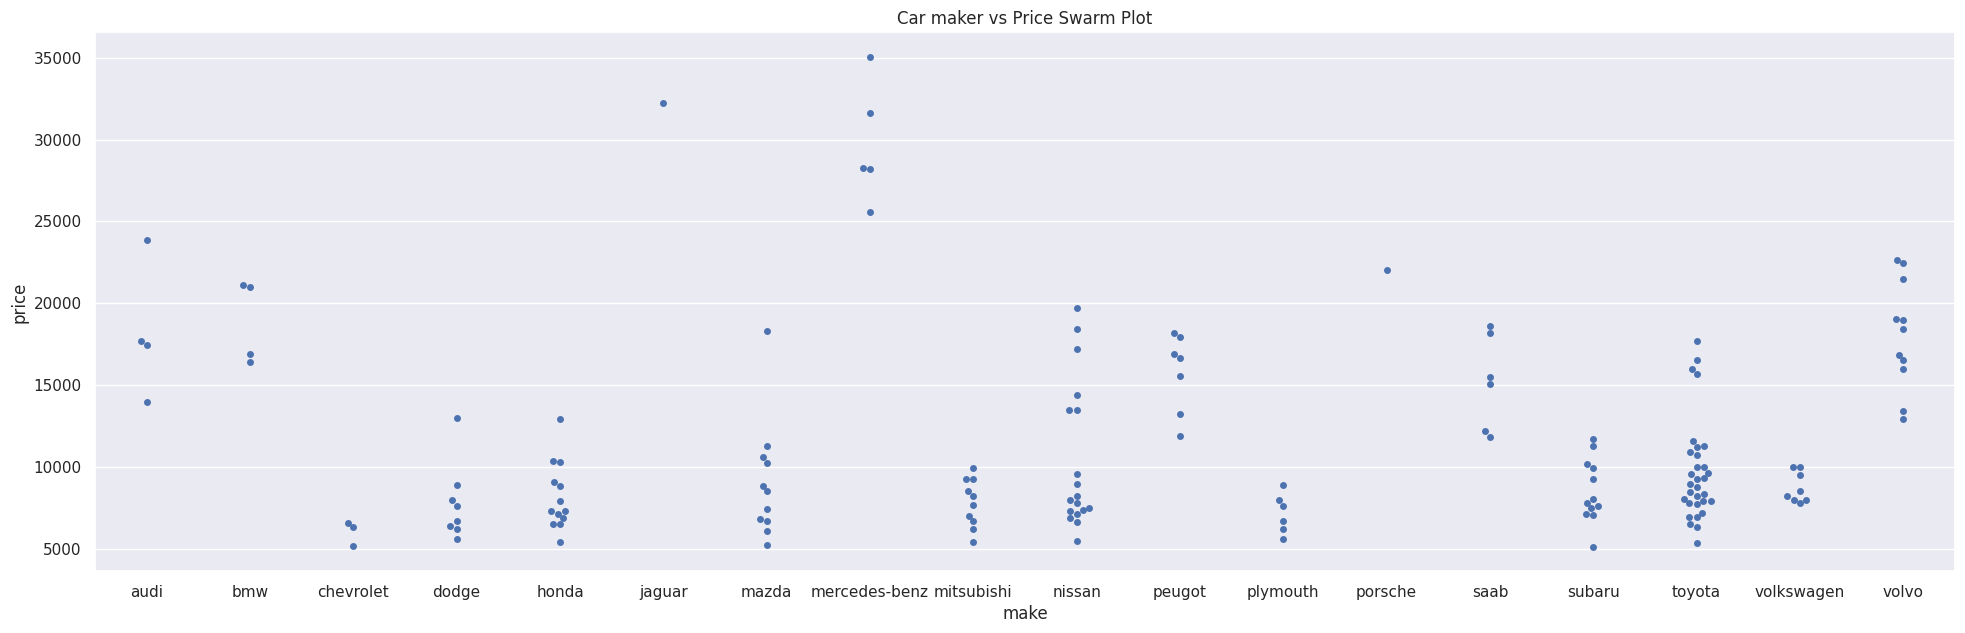

In [10]:
sns.swarmplot(x=X["make"],y=y).set_title('Car maker vs Price Swarm Plot')

/tmp/ipykernel_2308/541565243.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=X["make"],y=pd.to_numeric(X["horsepower"]), palette="Set3").set_title('Car maker vs Horsepower Box Plot')


Text(0.5, 1.0, 'Car maker vs Horsepower Box Plot')

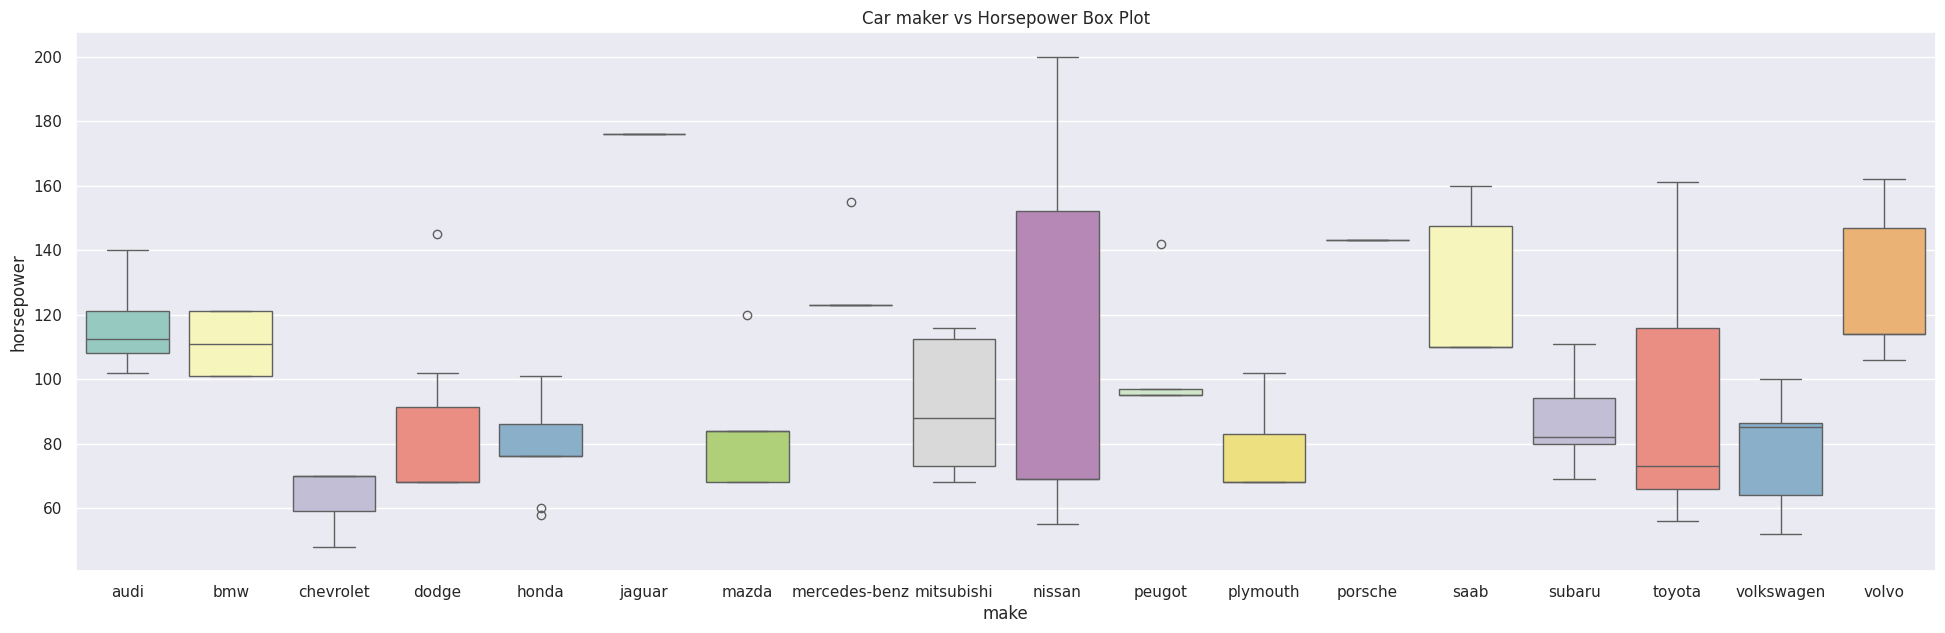

/tmp/ipykernel_2308/541565243.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=X["make"],y=pd.to_numeric(X["horsepower"]), palette="Set3").set_title('Car maker vs Horsepower Box Plot')


Text(0.5, 1.0, 'Car maker vs Horsepower Box Plot')

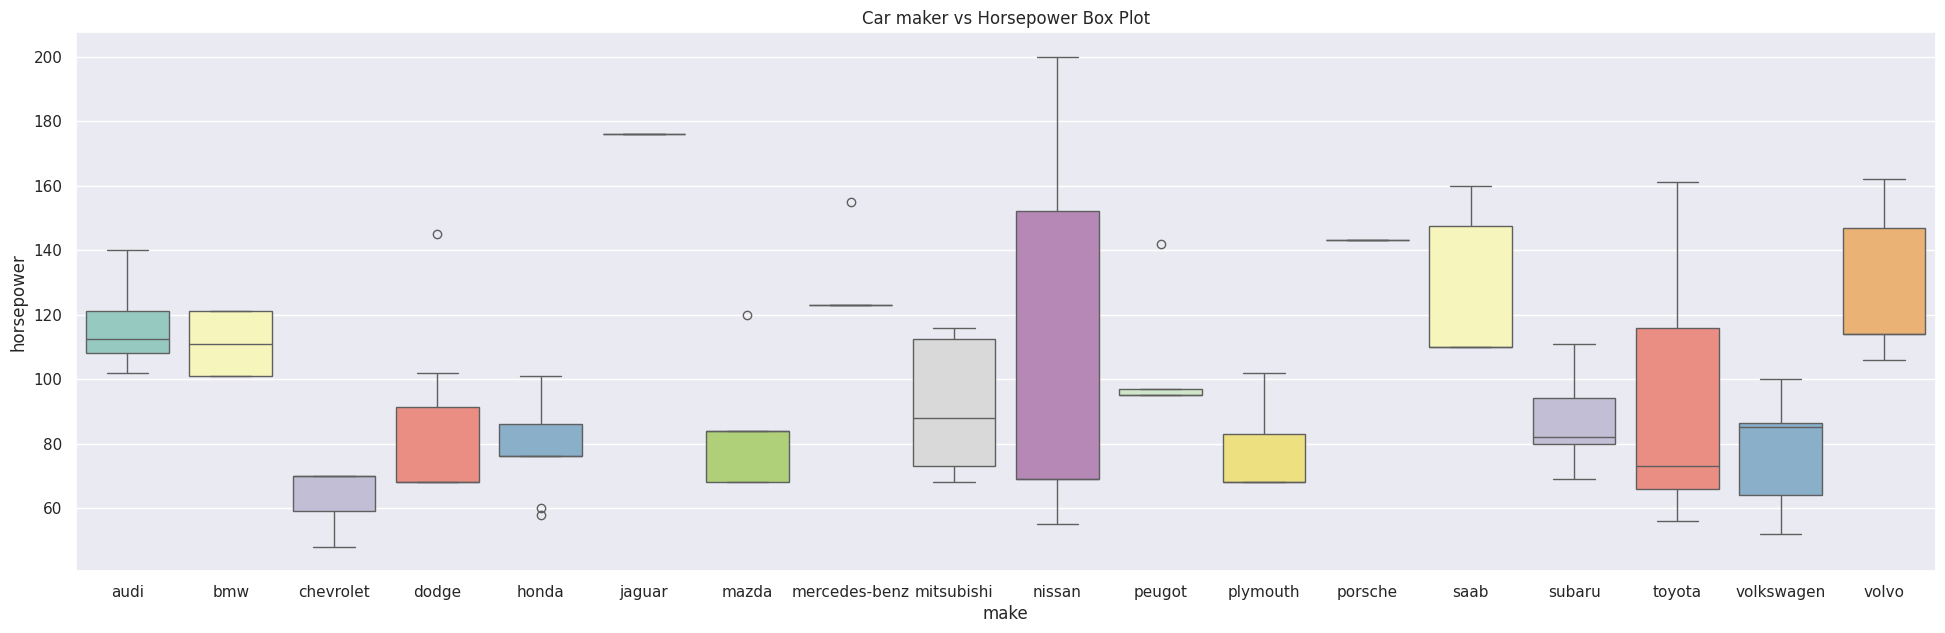

In [12]:
sns.boxplot(x=X["make"],y=pd.to_numeric(X["horsepower"]), palette="Set3").set_title('Car maker vs Horsepower Box Plot')

<Axes: xlabel='horsepower', ylabel='price'>

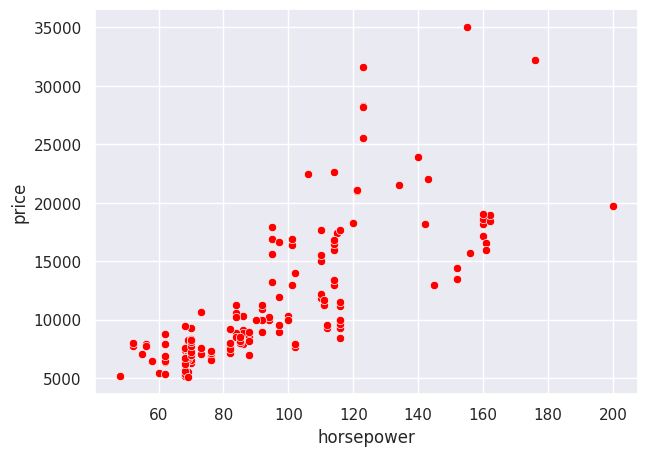

In [13]:
sns.set(rc={'figure.figsize':(7,5)})
sns.scatterplot(x=pd.to_numeric(X["horsepower"]), y = y, color = "red")

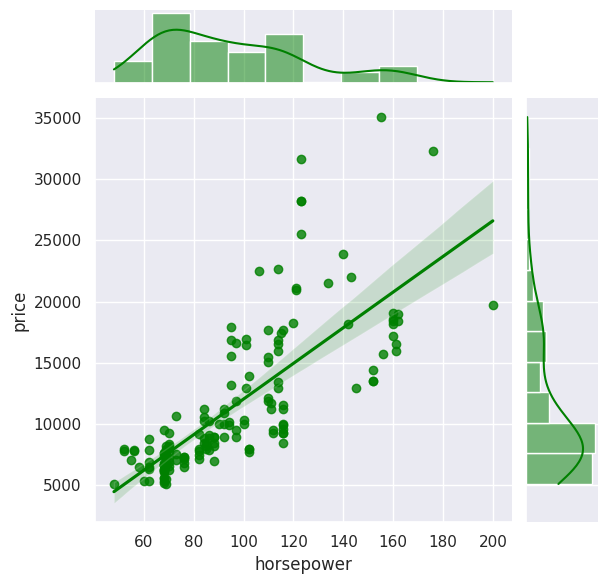

In [14]:
sns.jointplot(x=pd.to_numeric(X["horsepower"]), y = y, kind="reg", color = 'green')

## Exercise: Plot the jointplot for a feature which has negative correlation with the target variable "price".

An example is shown below, with "highway-mpg" where MPG is miles per gallon.

### Hint: You should be using numeric features. The numeric features in the data are listed below:

'symboling', 'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-size', 'bore', 'stroke', 'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg'

#### You are motivated to try all of these features to better understand the dataset

Text(0.5, 1.02, 'City MPG vs Price')

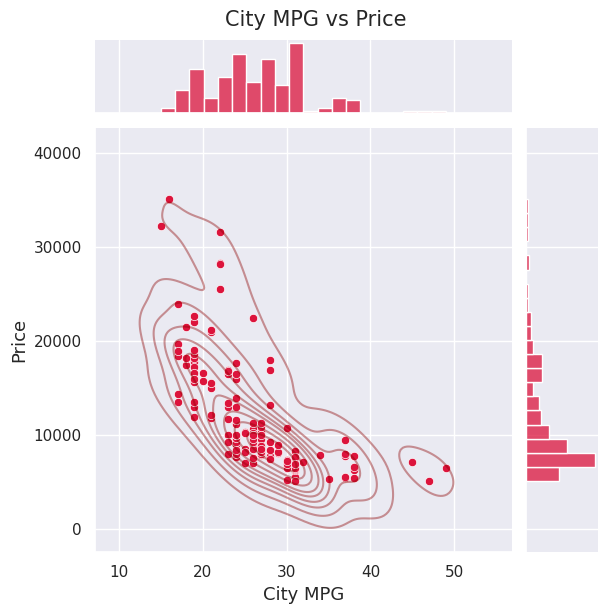

In [16]:
feature = "city-mpg"
g = sns.jointplot(x=pd.to_numeric(X[feature]), y=y, kind="scatter",
                  color='crimson', marginal_kws=dict(bins=20, fill=True))
g.plot_joint(sns.kdeplot, color="darkred", alpha=0.4, zorder=1)
g.set_axis_labels("City MPG", "Price", fontsize=13)
g.figure.suptitle("City MPG vs Price", fontsize=15, y=1.02)

## Question: Interpreting Body Style vs. Price
Let's analyze the plot below, which shows the relationship between a car's body-style and its price.

Based on the plot, answer the following questions:

- Which body-type has the highest median price? Which one appears to be the "costliest" overall?
- Is looking only at the maximum value (the top whisker or outlier) a good way to determine the costliest body-style? Why is the interquartile range (the box) a better indicator?
- Do you think the body-style of a car could be a good predictor for its price? Why or why not?


1. Which body-type has the highest median price? Which is "costliest" overall?

Hardtop and convertible typically have the highest median price from the box plot.
Convertible appears to be the "costliest" overall, as it tends to have the highest upper range and outliers.

2. Is the maximum value (top whisker/outlier) a good way to determine costliest body-style? Why is IQR better?

No, looking only at the maximum is not a good approach because:

A single outlier can be a rare, extreme case that doesn't represent the typical car in that category.
For example, one extremely expensive sedan doesn't mean sedans are generally costly.

IQR (the box) is better because:

It represents the middle 50% of the data — the typical price range for most cars in that body-style.
It is robust to outliers and gives a more reliable picture of where prices truly lie for a given body-style.

3. Is body-style a good predictor for price?

Partially yes, because:

Different body-styles do show distinctly different price distributions (e.g., convertibles are clearly more expensive than hatchbacks).
This means body-style carries some predictive signal.

But not alone, because:

There is significant overlap between some body-styles (e.g., sedan vs. wagon).
The spread within each category is large, meaning body-style alone cannot precisely predict price.
It works better as one feature among many in a model.

/tmp/ipykernel_2308/1765729027.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=X["body-style"],y=y, palette="Set3").set_title('Body style vs Price Box Plot')


Text(0.5, 1.0, 'Body style vs Price Box Plot')

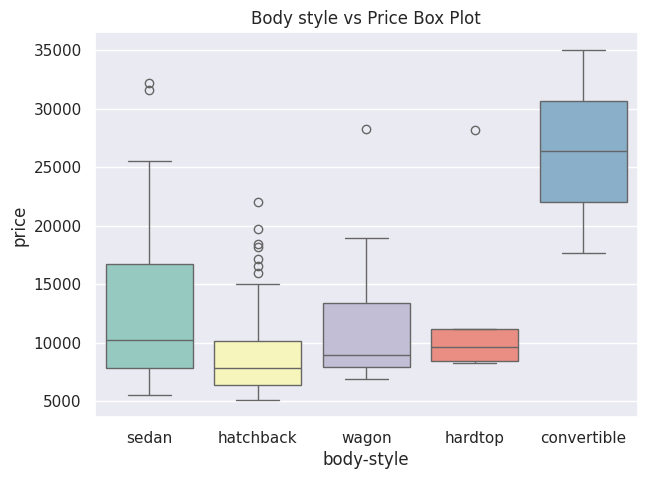

In [17]:
sns.boxplot(x=X["body-style"],y=y, palette="Set3").set_title('Body style vs Price Box Plot')

### Exercise
Often, you want to display multiple plots side-by-side to compare them. Matplotlib's plt.subplots() function is perfect for this. It creates a figure and a grid of subplots (axes).

**Task:** Choose any 2 plot types discussed above (e.g., a Box Plot and a Violin Plot) and plot them together in a single figure for body-style vs. price.


/tmp/ipykernel_2308/3468472353.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2308/3468472353.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


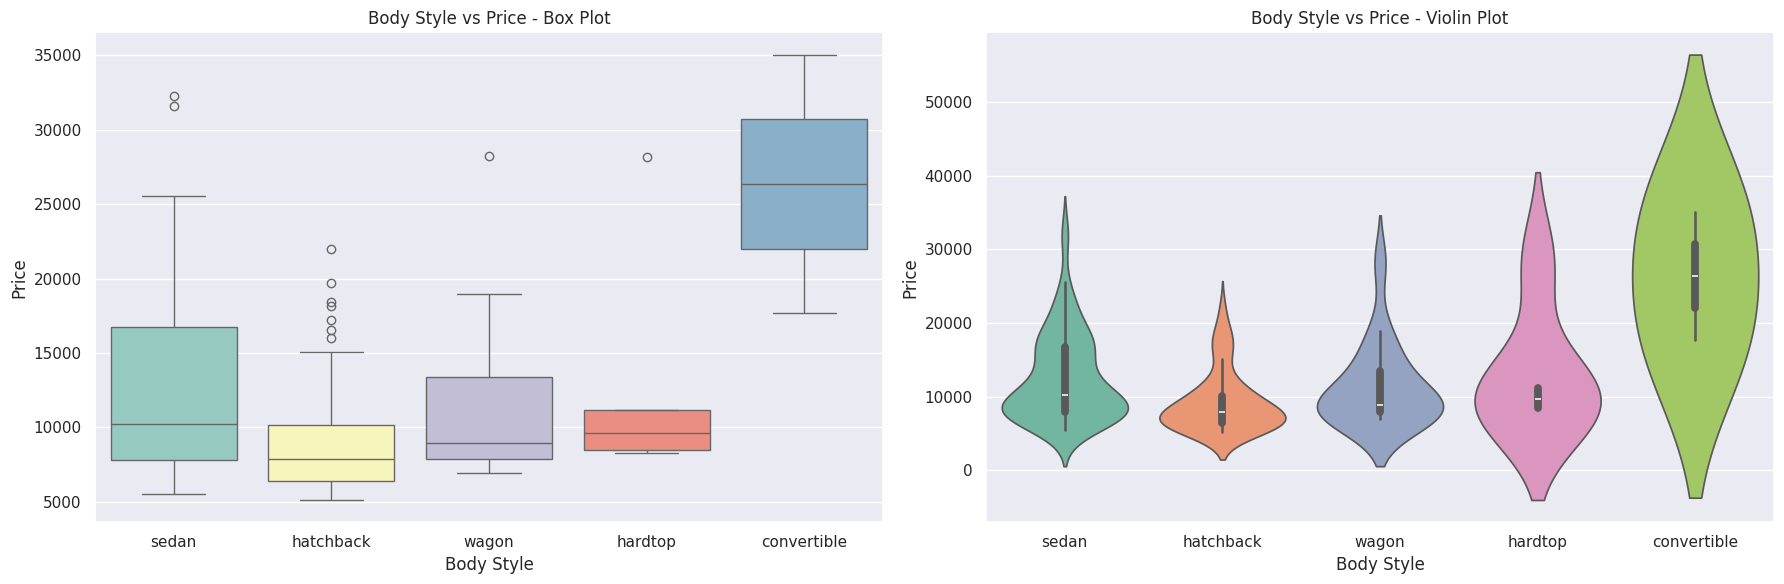

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Box Plot
sns.boxplot(
    x=X["body-style"],
    y=y,
    palette="Set3",
    ax=axes[0]
)
axes[0].set_title("Body Style vs Price - Box Plot")
axes[0].set_xlabel("Body Style")
axes[0].set_ylabel("Price")

# Violin Plot
sns.violinplot(
    x=X["body-style"],
    y=y,
    palette="Set2",
    ax=axes[1]
)
axes[1].set_title("Body Style vs Price - Violin Plot")
axes[1].set_xlabel("Body Style")
axes[1].set_ylabel("Price")

plt.tight_layout()
plt.show()